## ESTIMATION DISTRIBUTION ALGORITHMS

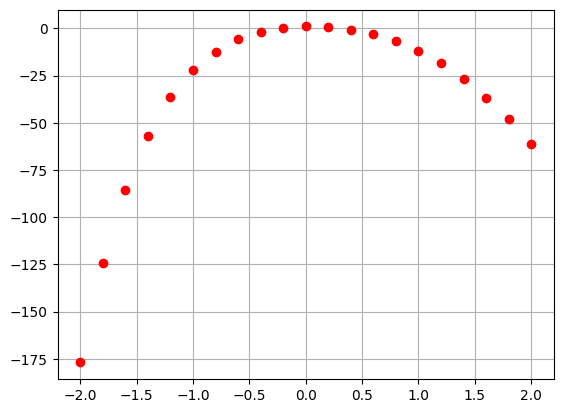

In [14]:

import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 

datos = pd.read_excel('data.xlsx')
x = datos['x']
y = datos['y']
plt.plot(x,y,'ro')
plt.grid()

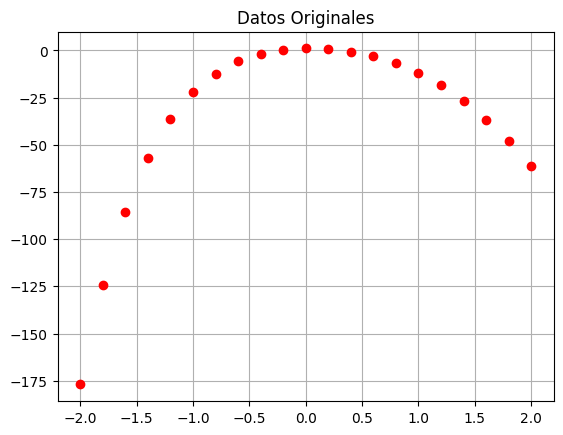

Generación 1 | Mejor MSE actual: 379.7671
Generación 2 | Mejor MSE actual: 157.5076
Generación 3 | Mejor MSE actual: 43.1740
Generación 4 | Mejor MSE actual: 39.6657
Generación 5 | Mejor MSE actual: 39.6657
Generación 6 | Mejor MSE actual: 39.6657
Generación 7 | Mejor MSE actual: 12.8581
Generación 8 | Mejor MSE actual: 12.8581
Generación 9 | Mejor MSE actual: 12.8581
Generación 10 | Mejor MSE actual: 12.8581
Generación 11 | Mejor MSE actual: 11.9134
Generación 12 | Mejor MSE actual: 10.2914
Generación 13 | Mejor MSE actual: 10.2914
Generación 14 | Mejor MSE actual: 8.8222
Generación 15 | Mejor MSE actual: 8.8222
Generación 16 | Mejor MSE actual: 8.5877
Generación 17 | Mejor MSE actual: 6.3125
Generación 18 | Mejor MSE actual: 6.3125
Generación 19 | Mejor MSE actual: 6.2368
Generación 20 | Mejor MSE actual: 6.2368
Generación 21 | Mejor MSE actual: 6.2368
Generación 22 | Mejor MSE actual: 6.2368
Generación 23 | Mejor MSE actual: 6.2368
Generación 24 | Mejor MSE actual: 6.2368
Generación

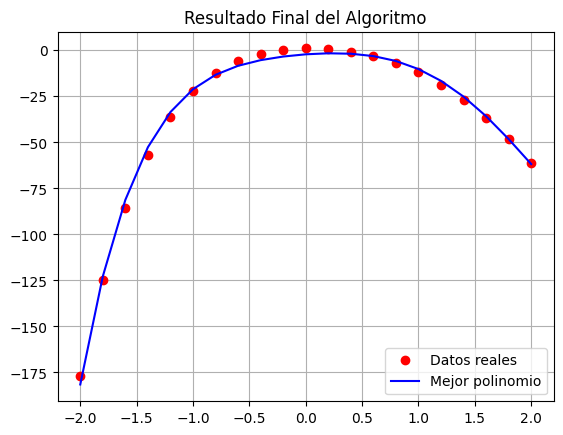


--- Resultados ---
Mejor individuo (coeficientes a0..a5): [-2.17052697  4.43698583 -8.02772345 -0.74097362 -5.46181633  1.77911317]
MSE del mejor individuo: 6.118269848937006


In [16]:
# Importamos las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Cargamos los datos desde el archivo de Excel
datos = pd.read_excel('data.xlsx')
x = datos['x']
y = datos['y']

# Graficamos los datos originales
plt.plot(x,y,'ro')
plt.grid()
plt.title('Datos Originales')
plt.show()

# --- DEFINIMOS LAS FUNCIONES DEL ALGORITMO ---

def generar_poblacion(tam_pob, num_ind, Imin, Imax):
    """Genera una población inicial de individuos aleatorios."""
    poblacion = np.zeros((tam_pob, num_ind))
    for i in range(tam_pob):
        for j in range(num_ind):
            poblacion[i][j] = np.random.uniform(Imin, Imax)
    return poblacion

def evaluar(Poblacion, x, y):
    """Evalúa el fitness (MSE) de cada individuo en la población."""
    [r, c] = Poblacion.shape
    n = len(y)
    evaluaciones = np.zeros((r, n))
    fitness = np.zeros(r)
    for i in range(r):
        # Evalúa el polinomio para cada individuo
        y_new = Poblacion[i,0]*x**0 + Poblacion[i,1]*x**1 + Poblacion[i,2]*x**2 + Poblacion[i,3]*x**3 + Poblacion[i,4]*x**4 + Poblacion[i,5]*x**5
        y_new_np = np.array(y_new)
        evaluaciones[i,:] = y - y_new_np
        
        # Calcula el fitness (Error Cuadrático Medio)
        fitness[i] = np.mean(evaluaciones[i,:]**2)
    return fitness

def seleccion(Poblacion, fitness, ps):
    """Selecciona a la élite de la población por truncamiento."""
    [r, c] = Poblacion.shape
    indices_ordenados = np.argsort(fitness)
    tamano_elite = int(r * ps)
    Poblacion_elite = np.zeros((tamano_elite, c))
    for i in range(tamano_elite):
        Poblacion_elite[i,:] = Poblacion[indices_ordenados[i],:]
    return Poblacion_elite

def nueva_generacion(tam_poblacion, poblacion_elite):
    """
    Genera una nueva población a partir de la élite
    usando un modelo gaussiano simple.
    """
    media = np.mean(poblacion_elite, axis=0)
    desv_est = np.std(poblacion_elite, axis=0)
    
    nueva_poblacion = np.zeros((tam_poblacion, len(media)))
    
    for i in range(len(media)):
        nueva_poblacion[:, i] = np.random.normal(media[i], desv_est[i], tam_poblacion)
    
    return nueva_poblacion

# --- PARÁMETROS DEL ALGORITMO ---

tam_poblacion = 100
porcentaje_trunc = 0.5
n_generaciones = 100
n_genes = 6
rango = (-10, 10)

# --- BUCLE PRINCIPAL DE GENERACIONES ---

# Población inicial
poblacion = generar_poblacion(tam_poblacion, n_genes, rango[0], rango[1])

# Para guardar el mejor MSE y coeficientes
mejor_mse = float('inf')
mejor_individuo = None

for gen in range(n_generaciones):
    # a) Evaluamos el fitness de toda la población
    fitnesss = evaluar(poblacion, x, y)
    
    # b) Seleccionamos la élite por truncamiento
    poblacion_seleccionada = seleccion(poblacion, fitnesss, porcentaje_trunc)
    
    # c) Guardamos el mejor individuo de la generación
    idx_mejor = np.argmin(fitnesss)
    if fitnesss[idx_mejor] < mejor_mse:
        mejor_mse = fitnesss[idx_mejor]
        mejor_individuo = poblacion[idx_mejor].copy()
    
    # d) Generamos la nueva población usando el modelo gaussiano
    poblacion = nueva_generacion(tam_poblacion, poblacion_seleccionada)
    
    # e) Mostramos el progreso
    print(f"Generación {gen+1} | Mejor MSE actual: {mejor_mse:.4f}")

# --- RESULTADOS FINALES Y GRÁFICO ---

# Evaluamos el mejor polinomio encontrado
y_pred = (mejor_individuo[0]*x**0 + mejor_individuo[1]*x**1 + mejor_individuo[2]*x**2 + 
          mejor_individuo[3]*x**3 + mejor_individuo[4]*x**4 + mejor_individuo[5]*x**5)

# Graficamos el resultado
plt.figure()
plt.plot(x, y, 'ro', label='Datos reales')
plt.plot(x, y_pred, 'b-', label='Mejor polinomio')
plt.grid()
plt.legend()
plt.title('Resultado Final del Algoritmo')
plt.show()

print("\n--- Resultados ---")
print("Mejor individuo (coeficientes a0..a5):", mejor_individuo)
print("MSE del mejor individuo:", mejor_mse)